# Estimación espectral no-paramétrica: LIGO

**22.46 Procesamiento Adaptativo de Señales Aleatorias — Trabajo Práctico 1**

---

# Grupo N° 6

| Integrante | Legajo |
|---|---|
| *Pedro Stefoni Rey Iraola* | *64903* |
| *Vito Pensa Piccolo* | *63426* |
| *Javier Baltasar Pérez Losada* | *(completar)* |

**Fecha de entrega:** 8/9/2026

---

> **Cómo se entrega.** Este notebook **es** el informe. Completen la portada de arriba,
> resuelvan cada inciso en su sección correspondiente **sin alterar el orden ni la numeración**,
> y dejen en cada celda de respuesta la justificación escrita: las decisiones de parametrización
> son el contenido evaluado, no un detalle de implementación.
>
> Entreguen el notebook **ejecutado de principio a fin y guardado con las salidas visibles**,
> con el nombre `TP1_LIGO_Grupo<N>.ipynb`. Usen rutas relativas a `data/` y **no incluyan los archivos de datos**
> en la entrega. El notebook debe correr de arriba a abajo sin intervención manual.

## Presentación

En este trabajo deberán analizar la onda gravitatoria **GW150914**, la primera detección directa de la historia. Fue registrada por el proyecto **LIGO** (Laser Interferometer Gravitational-Wave Observatory) el 14 de septiembre de 2015, y corresponde a la fusión de dos agujeros negros de 36 y 29 masas solares a unos 1300 millones de años luz.

El interés para esta materia es instrumental: **la señal llega enterrada bajo un ruido que la supera ampliamente, sobre un instrumento cuyo espectro abarca varias décadas de amplitud**. Todo el trabajo consiste en estimar bien ese ruido y usar esa estimación para recuperar la señal.

### Los detectores

Cada detector es un interferómetro de Michelson con brazos de 4 km y cavidades Fabry-Perot. Lo que mide es la **deformación** relativa del espacio, o *strain*:

$$h(t) = \frac{\Delta L(t)}{L}$$

Para GW150914 el pico fue $h \approx 10^{-21}$: un cambio de longitud de brazo de $4 \times 10^{-18}\,\mathrm{m}$, cuatro órdenes de magnitud por debajo del diámetro de un protón. Tengan presente esa cifra cuando evalúen qué tan cerca del ruido está lo que buscan.

Hay dos detectores, en Hanford (Washington) y en Livingston (Louisiana), separados por $d = 3002\,\mathrm{km}$. Como las ondas gravitatorias viajan a la velocidad de la luz, el retardo entre ambos está acotado por

$$\Delta t_{\max} = \frac{d}{c} \approx 10\,\mathrm{ms}$$

En la notación de GWOSC, **H1** es Hanford y **L1** es Livingston.

### El ruido de fondo

La sensibilidad está limitada por varias contribuciones simultáneas, cada una dominante en una región distinta del espectro:

<img src="ligo_noise.png" alt="LIGO Noise" width="400px"/>

**Atención: es una curva de diseño esquemática, no una medición.** Indica qué mecanismos limitan la sensibilidad y dónde domina cada uno, pero los niveles absolutos no corresponden al instrumento con el que van a trabajar.

A esto se suman **componentes tonales**: modos mecánicos de las suspensiones, líneas de red y sus armónicas, líneas inyectadas para calibración, resonancias de la óptica.

### El set de datos

Los datos son públicos y están en **GWOSC** (Gravitational Wave Open Science Center): [gwosc.org/events/GW150914](https://gwosc.org/events/GW150914/)

Descarguen los datos de *strain* a **4096 Hz** para H1 y L1. Para cada detector hay dos archivos HDF5:

| Archivo | Duración | Uso previsto |
|---|---|---|
| Ventana corta centrada en el evento | 32 s | Whitening y DOA (puntos 3 y 4) |
| Ventana larga | 4096 s | Espectro de ruido (punto 2) |

Los nombres siguen el patrón `<D>-<D1>_LOSC_4_V2-<GPS_inicio>-<duración>.hdf5`, por ejemplo `H-H1_LOSC_4_V2-1126259446-32.hdf5`.

El evento es una señal de tipo **chirp** que ocurre cerca del tiempo GPS $1126259462{,}4\,\mathrm{s}$ y dura aproximadamente $200\,\mathrm{ms}$. Puede verse y escucharse en [este video](https://www.youtube.com/watch?v=QyDcTbR-kEA).

### Notas de implementación

- **Grafiquen siempre en escala log-log.** Con este rango dinámico, un gráfico lineal no muestra nada.
- Es habitual reportar la **amplitud** espectral $\sqrt{S_x(f)}$ en $1/\sqrt{\mathrm{Hz}}$ en lugar de la potencia. Elijan una convención y sean consistentes.
- Verifiquen la **normalización** de sus estimadores: una PSD mal escalada por el factor de la ventana pasa desapercibida en escala logarítmica pero arruina el whitening.
- Usen `sosfiltfilt` en lugar de `lfilter`: un corrimiento de fase entre H1 y L1 destruiría la estimación de retardo del punto 4.
- Documenten **todas** las decisiones de parametrización ($N$, $L$, $K$, ventana, solapamiento, banda) y su justificación.

> **Sobre el Anexo.** Al final de este notebook hay un anexo con valores publicados por la colaboración LIGO, dentro de una sección plegada. **Ábranlo recién después de haber producido sus propios resultados**, y usen la comparación como material de discusión.

## 0. Preparación

Celda de configuración común. Ajusten `DATA` si sus archivos están en otro lado.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import h5py                              # lectura de los HDF5 de GWOSC
from pathlib import Path
from scipy.signal import welch, periodogram, correlate
from scipy.signal import butter, sosfiltfilt
from scipy.signal.windows import tukey, hann
from scipy.interpolate import interp1d
from scipy.io import wavfile             # exportación del audio

DATA = Path("data")                      # carpeta con los .hdf5 descargados de GWOSC
FS = 4096                                # Hz
GPS_EVENTO = 1126259462.4                # s


def leer_strain(path):
    """Devuelve (strain, t0, dt) de un archivo de strain de GWOSC."""
    with h5py.File(path, "r") as f:
        strain = f["strain"]["Strain"][:]
        t0 = f["strain"]["Strain"].attrs["Xstart"]
        dt = f["strain"]["Strain"].attrs["Xspacing"]
    return strain, t0, dt


plt.rcParams["figure.figsize"] = (10, 4)

h1_largo = next(DATA.glob("H-H1*-4096.hdf5"))
h1_corto = next(DATA.glob("H-H1*-32.hdf5"))
l1_largo = next(DATA.glob("L-L1*-4096.hdf5"))
l1_corto = next(DATA.glob("L-L1*-32.hdf5"))

---

## 1. Investigación preliminar

Investiguen cómo funcionan los detectores de LIGO y escriban un resumen breve que cubra los mecanismos físicos que limitan la sensibilidad y en qué banda domina cada uno, qué tipo de artefactos aparecen en los datos (líneas espectrales, transitorios, no estacionariedad) y qué rango dinámico esperan encontrar en la amplitud espectral.

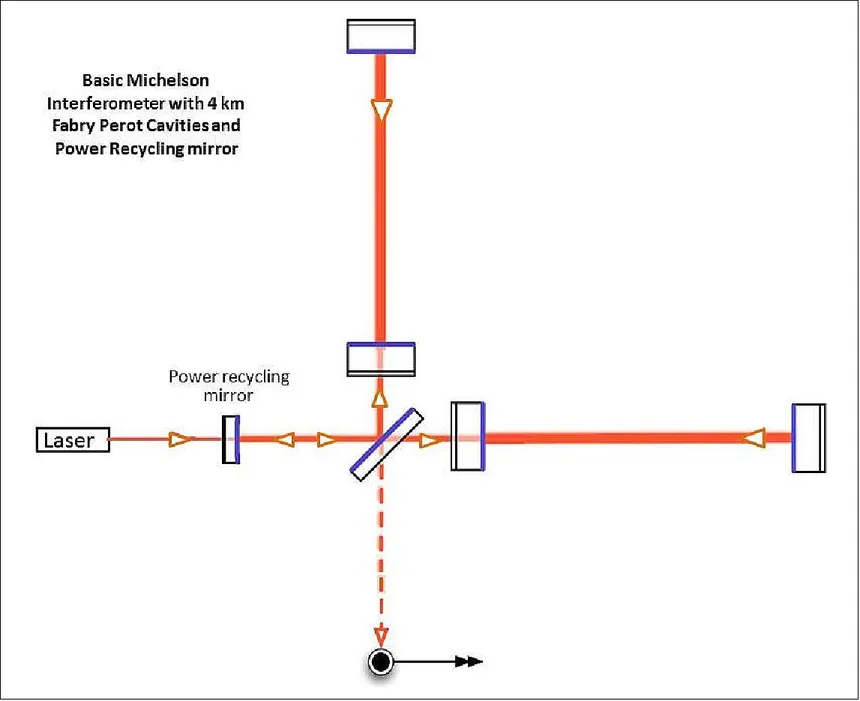

Los detectores de LIGO usan la interferencia de un haz de luz que ha sido dividido para calcular cómo fueron las ondas gravitacionales que causaron esa variación en la interferencia. Como muestra la imagen de arriba, ambos haces antes de ser divididos por el "beam splitter" parten de una misma fuente. Luego de esa separación, cada haz recorre exactamente la misma distancia hasta encontrarse con un espejo, que rebota el haz en esa misma dirección. Luego, al encontrarse ambos haces de nuevo en el beam splitter, forman un mismo haz de nuevo. Ese nuevo haz "reconstruido" se dirige hacia un fotodetector, el cual es capaz de medir ese nuevo haz. Cuando llega una onda gravitacional, el tramo que recorrió cada haz al separarse varía en longitud, debido a los estiramientos producidos por esa onda. Esto logra que varíe la interferencia vista por el fotodetector, logrando así medir el impacto de la onda gravitacional. En este video se visualiza este fenómeno.

https://www.youtube.com/watch?v=DfVl6sBnu7Y

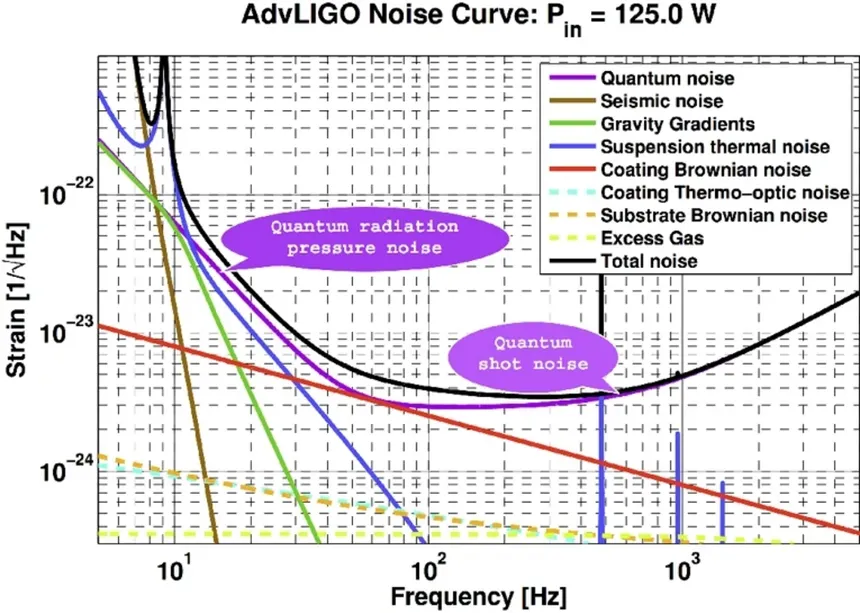

Entonces, tiene sentido que cualquier tipo de generador de movimiento en cualquiera de los 4 puntos (generador del haz, beam splitter, espejo y fotómetro) genera imprecisiones (ruido) en la medición. Encontramos que hay 3 fuentes principales de ruido, según se puede ver en la imagen. A bajas frecuencias, hay una fuerte presencia del ruido sísmico propio de las vibraciones naturales y la actividad humana. A pesar de lo robusto e inamivible que puede ser el interferómetro, estamos en escalas subatómicas (el pico de ruido a estudiar fue de 4 x 10^(-18)), por lo que genera un piso de ruido. Luego, encontramos el ruido térmico ocasionado por la vibración de las partículas al estar en una temperatura mayor a 0 grados Kelvin. Esta vibración coasiona errores de medición en la superficie del dieléctrico que hace al beam splitter y al fotodetector. Por último, a altas frecuencias encontramos el ruido de medición ocasionado por la incerteza por el principio de incertidumbre de Heisenberg y la función de onda de Schrodinger. Los coeficientes probabilísticos que tiene el fotón como onda fluctúa y junto con el principio de incertidumbre hace que no se pueda saber con precisión toda la información del fotón cuando impacta con el fotómetro. Está la relación de compromiso entre en qué momento lo impactó y la energía que tenía, vista en la asignatura Física IV. Como ocurre al momento del impacto, este fenómeno se llama "shot noise". 


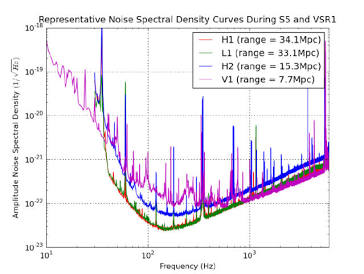

Vemos que hay picos espectrales en los 60 Hz y sus armónicos, debido al acoplamiento magnético con la frecuencia de la red eléctrica en EEUU. También hay un pico en los 500 Hz, causado por las vibraciones de las fibraciones de silicio sobre las cuales se sostienen los espejos mencionados en el primer párrafo.

Por otro lado, hay transitorios en el espectro, llamado "ruido de banda ancha". Esto es porque este ruido es temporal y abarca varias frecuencias, como un chirp. Suelen ser producidos por micro-sismos locales, inestabilidades de la red eléctrica, e incluso vibraciones producidas por camiones circulando a la distancia.

Por último, sobre la estacionariedad del ruido mencionado, claramente no estamos ante un caso de ruido estacionario. Si lo fuese, no usaríamos algoritmos de procesamiento adaptativo para tratar de recuperar la señal. Notemos que de todas las fuentes mencionadas, muchas se tratan de factores ambientales, que varían con el tiempo y son impredescibles.

---

## 2. Estimación del espectro de ruido

Estimen el espectro de potencia del ruido de H1 y L1 usando las partes de la señal que **no** involucran el evento. Justifiquen qué tramo excluyeron.

### 2.a — Periodograma

Estímenlo con el **periodograma**. Seleccionen y justifiquen la cantidad de datos $N$.

t0 = 1126257414, duración = 4096 s, fs = 4096 Hz
evento en índice 8390246 de 16777216
tramo: -6.0 s a -2.0 s respecto del evento
t0 = 1126257414, duración = 4096 s, fs = 4096 Hz
evento en índice 8390246 de 16777216
tramo: -6.0 s a -2.0 s respecto del evento


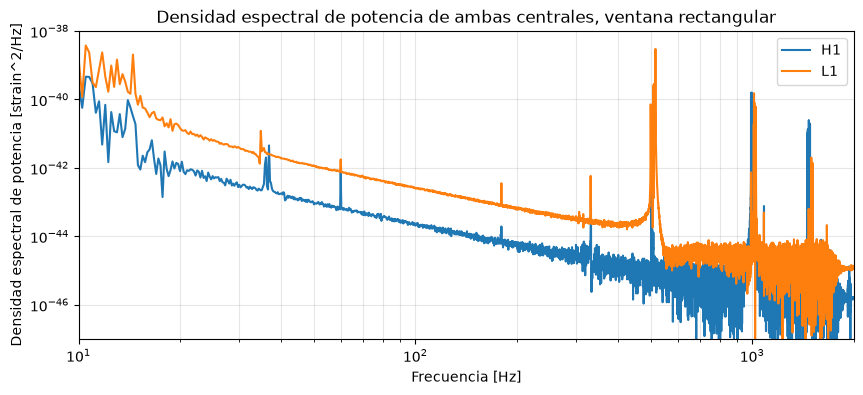

In [ ]:
strainh, t0h, dth = leer_strain(h1_largo)
print(f"t0 = {t0h}, duración = {len(strainh)*dth:.0f} s, fs = {1/dth:.0f} Hz") 
print(f"evento en índice {(GPS_EVENTO - t0h)/dth:.0f} de {len(strainh)}") #pongo esto para chequear que el archivo es correcto, tuve problemas con eso
t = t0h + np.arange(len(strainh)) * dth


N = 2**14 # = 16384, cantidad de muestras que voy a usar para el periodograma, que son un 4 segundos
i_evento = int((GPS_EVENTO - t0h) / dth) #calculo el GPS del evento en el archivo, para poder tomar un tramo de 10 segundos antes del evento
margen = 2.0                      # s antes del evento
i0h = i_evento - int(margen/dth) - N # el tramo TERMINA `margen` antes del evento
x_h = strainh[i0h : i0h + N] #armo el vector con el tramo de 4 segundos que voy a usar para el periodograma, que termina `margen` antes del evento
print(f"tramo: {(i0h-i_evento)*dth:.1f} s a {(i0h+N-i_evento)*dth:.1f} s respecto del evento") #print para chequear que el tramo es correcto

#Me había bajado los archivos equivocados de frecuencia, lo dejo comentado para re-chequeo futuro
fs_h, fs_l = 1/dth, 1/dtl
#print(fs_h, fs_l)

fh, Sh = periodogram(x_h, fs=fs_h, window="boxcar", scaling="density")

####### Repito con L1, acá hago copy paste ###########

strainl, t0l, dtl = leer_strain(l1_largo)
print(f"t0 = {t0l}, duración = {len(strainl)*dtl:.0f} s, fs = {1/dtl:.0f} Hz") 
print(f"evento en índice {(GPS_EVENTO - t0l)/dtl:.0f} de {len(strainl)}") #pongo esto para chequear que el archivo es correcto, tuve problemas con eso
t = t0l + np.arange(len(strainl)) * dtl

i0l = i_evento - int(margen/dtl) - N # el tramo TERMINA `margen` antes del evento
x_l = strainl[i0l : i0l + N] #armo el vector con el tramo de 4 segundos que voy a usar para el periodograma, que termina `margen` antes del evento
print(f"tramo: {(i0l-i_evento)*dtl:.1f} s a {(i0l+N-i_evento)*dtl:.1f} s respecto del evento") #print para chequear que el tramo es correcto


fl, Sl = periodogram(x_l, fs=fs_l, window="boxcar", scaling="density")

#Ahora grafico el espectro de potencia de ambas
plt.title("Densidad espectral de potencia de ambas centrales, ventana rectangular")
plt.loglog(fh, Sh, label="H1")
plt.xlim(10, 2000)
plt.ylim(1e-47, 1e-38)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [strain^2/Hz]")

#Ahora grafico el espectro de potencia de L1
plt.loglog(fl, Sl, label="L1")
plt.legend()
plt.grid(True, which="both", alpha=0.3) 



> **Respuesta.** *(completar)*

Recordemos que según vimos en la teórica, no hay un número ideal de N porque no mejora la varianza del periodograma. Lo que sí 
necesitamos ponderar es toda la parte de investigación de antes. Ya sabemos la frecuencia que tienen las distintas fuentes de ruido. Entonces, yo quiero que mi tamaño de muestra sea tal que pueda ver en el tiempo cada fuente de ruido varias veces. La traducción de este fenómeno también es que la resolución espectral se calcula como Δf = fs/N. Entonces si tomo N = 16384 (4 segundos de muestras) mi resolución espectral es 0,25Hz. Esto me va a permitir ver las líneas angostas de por ejemplo 60Hz sin verla como una punta ensanchada. Otro dato que me dí cuenta cuando ví que el archivo tardó como 15 minutos en descargarse (un montón de información), es que es una hora de grabación de datos teniendo el evento en el medio, como está indicado en la consigna más arriba. Tiene sentido entonces empezar a tomar datos más cerca del evento, no media hora antes, por la no estacionariedad que vimos antes. Esto último me dá una cota superior de N, porque si tomo un N gigante empiezo a tomar muestras mucho tiempo atrás (o después) del evento y por lo dicho recién no daría datos fidedignos.


Ahora que ploteamos el espectro, identificamos los picos a 500 Hz y su armónico en 1000Hz que habíamos mencionado antes. También hay una notoria caída de 35dB entre 40 Hz. y 1500 Hz. Eso resulta en una caída de 6dB por octava. Eso se condice con el leakage espectral que produciría el ruido sísmico (ruido a bajas frecuencias) junto con la ventana rectangular. Al superponer ambas, se vé que el ruido sísmico de la central en Livingston es mayor. Se concluye entonces que el piso de ruido sísmico a la hora del evento era mayor que la de Hanford. Sabiendo que en el punto 2.d hay que comparar ventanas, se deja la verificación de la hipótesis para ese punto.

### 2.b — Periodogram smoothing

Estímenlo con **periodogram smoothing**. Seleccionen y justifiquen $N$ y $L$. Iteren hasta obtener una buena estimación.

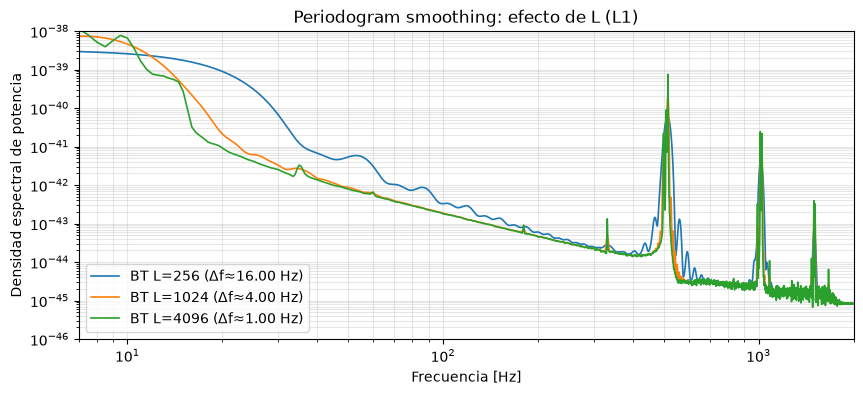

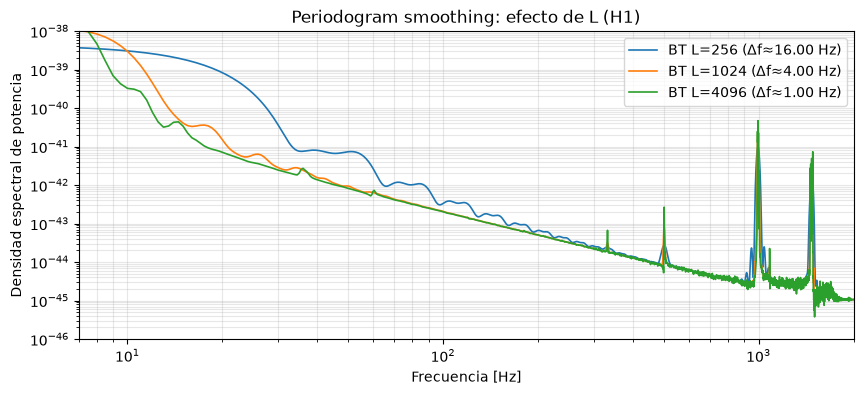

In [65]:
from scipy.signal.windows import parzen                        # ventana de correlación alternativa

def periodogram_smoothing(x, L, fs, nfft=4096, lag_window="parzen"):
    x = x - np.mean(x) # uso el mismo x de antes para tener la comparación, y le pongo media cero como pide la diapositiva
    N = len(x) # cantidad de muestras del tramo
    r_full = correlate(x, x, mode="full", method="fft") / N # r̂x(l) para todos los lags, dividido por N
    centro = N - 1 # índice donde queda el lag l = 0
    r = r_full[centro - (L-1) : centro + L] # me quedo con l = -(L-1) .. L-1
    # elijo la ventana de correlación
    if lag_window == "bartlett": 
        wa = np.bartlett(2*L - 1) # Bartlett de largo 2L-1, centrada en l = 0
    else:
        wa = parzen(2*L - 1) # idem con Parzen
    rw = r * wa # r̂x(l)·wa(l), el producto que va en la suma
    lags = np.arange(-(L-1), L) # el índice l de la sumatoria
    f = np.linspace(0, fs/2, nfft//2 + 1) # grilla de frecuencias donde evalúo
    S = np.array([np.sum(rw * np.exp(-2j*np.pi*fi*lags/fs)).real # la sumatoria, una frecuencia por vez
                  for fi in f]) # .real porque r̂x·wa es par: la parte imag es 0
    return f, S / fs * 2 # normalizo a PSD unilateral en unidades/Hz

for L in [256, 1024, 4096]: # barro L para ver cómo varía
    f_bt, S_bt = periodogram_smoothing(x_l, L, fs_l, nfft=8192) # mismo tramo x, mismo N que antes
    df = fs_l / L # resolución aproximada de esta elección
    plt.loglog(f_bt, S_bt, lw=1.2, label=f"BT L={L} (Δf≈{df:.2f} Hz)")

plt.xlim(7, 2000)                                            
plt.ylim(1e-46, 1e-38)                                         
plt.xlabel("Frecuencia [Hz]")                                  
plt.ylabel("Densidad espectral de potencia")      
plt.title("Periodogram smoothing: efecto de L (L1)")           
plt.legend()                                                   
plt.grid(True, which="both", alpha=0.3)

plt.figure()

for L in [256, 1024, 4096]: # barro L para ver cómo varía
    f_bt, S_bt = periodogram_smoothing(x_h, L, fs_h, nfft=8192) # mismo tramo x, mismo N que antes
    df = fs_h / L # resolución aproximada de esta elección
    plt.loglog(f_bt, S_bt, lw=1.2, label=f"BT L={L} (Δf≈{df:.2f} Hz)")

plt.xlim(7, 2000)                                            
plt.ylim(1e-46, 1e-38)                                         
plt.xlabel("Frecuencia [Hz]")                                  
plt.ylabel("Densidad espectral de potencia")      
plt.title("Periodogram smoothing: efecto de L (H1)")           
plt.legend()                                                   
plt.grid(True, which="both", alpha=0.3)

> **Respuesta.** *(completar)*

Comparando ambos gráficos con los mismos usados anteriormente, es visible que algunos picos disminuyeron drásticamente o desaparecieron. Por ejemplo, para el caso de los 60 Hz, ambos picos antes eran mucho más pronunciados mientras que ahora son sólo visibles tomando un L muy ancho tal que la resolución espectral logre distinguirla. A su vez, es notable cómo los casos con menor L dan teóricamente una menor varianza (o una mayor reducción de la varianza), pero trae una consecuencia mucho más grave, que es subir el piso de ruido por fuentes sísmicas. Esto ocurre por lo visto en la teórica, que E{R̂_x^(PS)} = R_x * W_B * W_a. En este caso, con un L chico el lóbulo que produce W_a es mucho más grande y aumenta el sesgo. Físicamente tiende sentido, si promedio tomando una longitud de vector muy chica las frecuencias más bajas no las veo en mi vector de promediado (L), tengo que aumentar su tamaño para poder distinguir el efecto de una señal que tarda varias muestras en hacerse ver (frecuencias bajas). Pero a su vez un L grande no me reduce la varianza, por lo que la solución sería agrandar N. En caso de hacerlo, pongo en compromiso la estacionariedad. Alternando entre Parzen y Bartlett se puede ver cómo Bartlett introduce un rizado periódico enorme 

### 2.c — Periodogram averaging

Estímenlo con **periodogram averaging**. Seleccionen y justifiquen $N$, $K$ y $L$. Iteren hasta obtener una buena estimación.

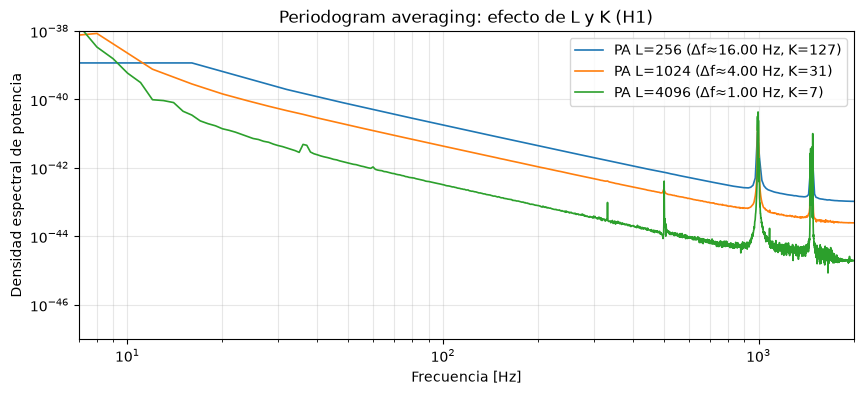

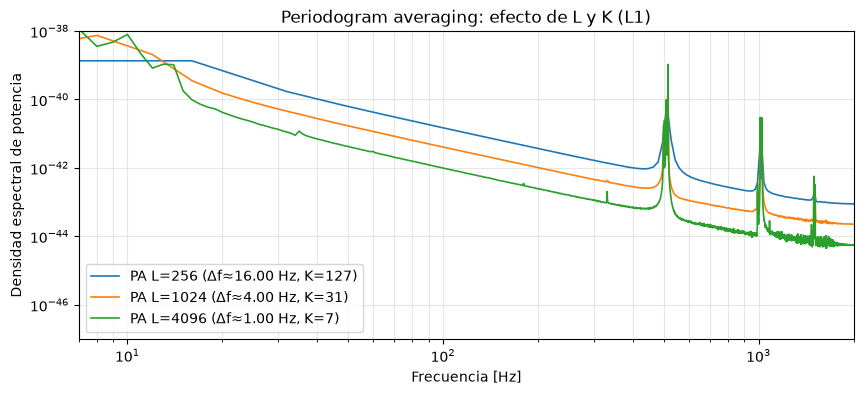

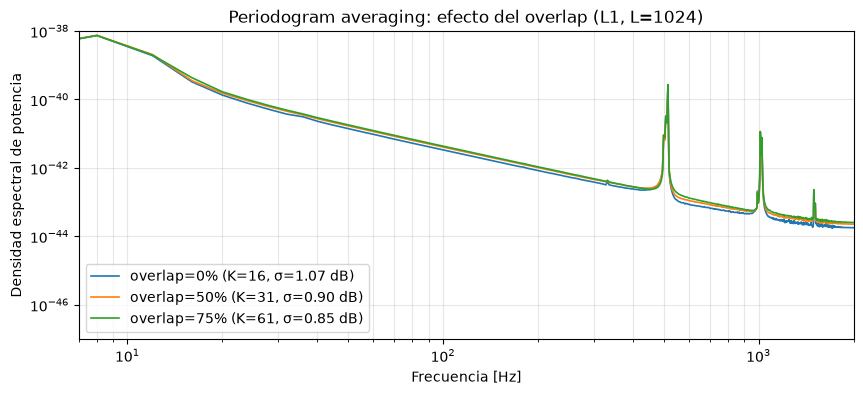

In [72]:
def periodogram_averaging(x, L, fs, overlap=0.5, ventana="rect"):
    x = x - np.mean(x) # misma idea que antes, le saco la media
    N = len(x) # cuántas muestras tengo en total
    if ventana == "hann": # elijo la ventana de datos
        w = hann(L, sym=False) # Hann, la que tiene taper
    else: 
        w = np.ones(L) # rectangular, para comparar
    w = w * np.sqrt(L / np.sum(w**2)) # normalizo así sum[w²(n)]=L, como pide la diapo
    D = int(L * (1 - overlap)) # el corrimiento entre segmentos
    K = 1 + (N - L)//D # cuántos segmentos me entran
    f = np.fft.rfftfreq(L, 1/fs) # las frecuencias que me da una FFT de L puntos
    S = np.zeros(len(f)) # acá voy acumulando los periodogramas
    for i in range(K): # recorro segmento por segmento
        xi = x[i*D : i*D + L] * w # xi(n) = x(iD+n)·w(n), tal cual la teórica
        Xi = np.fft.rfft(xi) # la DFT del segmento ventaneado
        S = S + np.abs(Xi)**2 / L  # le sumo su periodograma (1/L)|Xi|²
    S = S / K  # el promedio: divido por la cantidad de segmentos
    S = S / fs * 2  # paso a PSD unilateral en unidades/Hz
    S[0] = S[0]/2  # DC no se duplica
    S[-1] = S[-1]/2  # Nyquist tampoco
    return f, S, K # devuelvo también K para poder reportarlo


for L in [256, 1024, 4096]: # mismo barrido de L que en 2.b, para comparar
    f_pa, S_pa, K = periodogram_averaging(x_h, L, fs_h) # uso el mismo tramo x_h de siempre
    df_h = fs_h / L # la resolución que me da este L
    plt.loglog(f_pa, S_pa, lw=1.2, 
               label=f"PA L={L} (Δf≈{df_h:.2f} Hz, K={K})") # pongo K en la leyenda, que es lo que se reduce la varianza

plt.xlim(7, 2000) 
plt.ylim(1e-47, 1e-38) 
plt.xlabel("Frecuencia [Hz]")  
plt.ylabel("Densidad espectral de potencia") 
plt.title("Periodogram averaging: efecto de L y K (H1)")
plt.legend() 
plt.grid(True, which="both", alpha=0.3) 

plt.figure()

for L in [256, 1024, 4096]: # mismo barrido de L que en 2.b, para comparar
    f_pa, S_pa, K = periodogram_averaging(x_l, L, fs_l) # uso el mismo tramo x_h de siempre
    df_l = fs_l / L # la resolución que me da este L
    plt.loglog(f_pa, S_pa, lw=1.2, 
               label=f"PA L={L} (Δf≈{df_l:.2f} Hz, K={K})") # pongo K en la leyenda, que es lo que se reduce la varianza

plt.xlim(7, 2000) 
plt.ylim(1e-47, 1e-38) 
plt.xlabel("Frecuencia [Hz]")  
plt.ylabel("Densidad espectral de potencia") 
plt.title("Periodogram averaging: efecto de L y K (L1)")
plt.legend() 
plt.grid(True, which="both", alpha=0.3) 


plt.figure()
L = 1024 # fijo L: quiero que lo único que cambie sea el overlap

for ov in [0.0, 0.5, 0.75]: # sin solapamiento, 50% y 75%
    f_pa, S_pa, K = periodogram_averaging(x_l, L, fs_l, # mismo tramo y mismo L que siempre
                                          overlap=ov) # lo único que muevo
    banda = (f_pa > 1500) & (f_pa < 1900) # zona donde el espectro es casi plano
    disp = np.std(10*np.log10(S_pa[banda])) # dispersión en dB: mi medida de varianza
    plt.loglog(f_pa, S_pa, lw=1.2, #
               label=f"overlap={ov:.0%} (K={K}, σ={disp:.2f} dB)") # reporto K y la dispersión medida
plt.xlim(7, 2000) 
plt.ylim(1e-47, 1e-38) 
plt.xlabel("Frecuencia [Hz]") 
plt.ylabel("Densidad espectral de potencia") 
plt.title(f"Periodogram averaging: efecto del overlap (L1, L={L})") 
plt.legend()
plt.grid(True, which="both", alpha=0.3) 

> **Respuesta.** *(completar)*

Con overlap del 50%, L y K quedan atados: K ≈ 2N/L − 1. O sea que elegir L ya me determina K. Con N = 16384, el barrido L = 256, 1024, 4096 me da K = 127, 31, 7.

Lo que gano con K se ve arriba de 1500 Hz, donde el espectro es casi plano: con K = 7 la curva queda peluda, con K = 127 queda lisa. Pero lo que pierdo con L es mucho peor. A 100 Hz, L = 256 me da ~10⁻⁴¹ y L = 4096 me da ~10⁻⁴³: dos órdenes de magnitud de diferencia usando el mismo tramo de datos. Y la curva de L = 256 me queda horizontal entre 7 y 17 Hz, cosa que no es real: la de L = 4096 muestra que ahí el ruido sísmico sigue subiendo. Eso pasa porque E{R̂ₓ^(PA)} = Rₓ * R_w, y con Δf = 16 Hz la ventana es tan ancha que me arrastra potencia de una frecuencia a otra. Los picos de 500, 1000 y 1400 Hz dicen lo mismo: sólo aparecen con L = 4096.

Entonces acá el error que importa no es el de la varianza sino el de la resolución: la curva que mejor se ve (K = 127) es la que está más lejos del valor real.

Con el overlap, usando L = 1024 me dio K = 16, 31 y 61 para 0%, 50% y 75%, con dispersión de 1,07, 0,90 y 0,85 dB entre 1500 y 1900 Hz. Si los segmentos fueran independientes, duplicar K debería bajar la dispersión un 41%; me bajó 16% y después sólo 6%. Eso confirma lo que dice la teórica: al solaparse, los segmentos dejan de ser incorrelacionados y el promedio no me suma información nueva. Me quedo con 50%.

Elijo L = 4096, K = 7, que es el único que me deja ver las líneas y me describe bien el muro sísmico. Me queda poca reducción de varianza, lo que me dice que N = 16384 no alcanza y que tendría que agrandarlo, pagándolo con la estacionariedad.

### 2.d — Comparación de métodos

Determinen y justifiquen cuál de los tres produce la mejor estimación, discutiendo el compromiso entre resolución, sesgo y varianza. Incluyan en la discusión la elección de la **ventana**: dado el rango dinámico de este problema, comparen al menos una ventana con *taper* contra la rectangular.

> **Respuesta.** *(completar)*

### 2.e — H1 contra L1

Comparen las estimaciones de H1 y L1 entre sí: picos espectrales, artefactos, sesgo, varianza y cualquier otra cosa que les llame la atención. Atribuyan un origen a las componentes tonales que encuentren. ¿Cómo se compara lo que midieron con la curva esquemática de la presentación?

> **Respuesta.** *(completar)*

Esta respuesta fue abordada comparando los gráficos en puntos anteriores. Comparando los tres gráficos de 2.c, lo primero que se ve es que las dos centrales tienen la misma forma general: el muro sísmico abajo de 20 Hz, la caída suave en el medio y las líneas espectrales arriba de 300 Hz. Eso confirma que son dos instrumentos iguales midiendo el mismo tipo de ruido. Las diferencias están en las líneas. En L1 el pico de 500 Hz es muchísimo más grande que en H1, mientras que en H1 los que se destacan son los de 1000 y 1400 Hz. Como son los modos de las fibras de silicio que sostienen los espejos, tiene sentido que cada instalación tenga los suyos con distinta amplitud: dependen del armado mecánico particular de cada uno. La línea de 60 Hz y sus armónicos aparecen en las dos, porque las dos están conectadas a la misma red eléctrica.

Comparando con la curva esquemática de la presentación, la forma no me coincide: la curva de diseño tiene un mínimo entre 100 y 300 Hz y después vuelve a subir por el shot noise, y a mí el piso me sigue bajando hasta 2000 Hz. Eso me hace pensar que todavía tengo leakage de la ventana rectangular tapando el piso real. Lo verifico en 2.d comparando contra una ventana con taper.

### 2.f — Estacionariedad

**Validen la estacionariedad** de las señales. Investiguen técnicas de validación y aplíquenlas. ¿Sobre qué horizonte temporal es razonable tratar el ruido como estacionario?

> **Respuesta.** *(completar)*

---

## 3. Whitening

Con la mejor estimación del punto 2, realicen el **whitening** de los 32 s alrededor del evento: en el dominio de la frecuencia, normalicen cada componente por la amplitud espectral del ruido. Referencia útil: [los tutoriales de GWOSC](https://gwosc.org/tutorials/).

> **Whitening.** *(completar)*

### 3.a — Filtrado y visualización

Filtren pasabanda en la región de mayor sensibilidad, justificando los límites a partir de sus estimaciones del punto 2, y grafiquen la señal en el tiempo para ambos detectores. Deberían ver el chirp.

> **Respuesta.** *(completar)*

### 3.b — Audio

Generen el audio. El resultado directo es difícil de escuchar: expliquen por qué y qué transformación adicional aplicaron.

> **Respuesta.** *(completar)*

---

## 4. Dirección de arribo (DOA)

Con las señales del punto anterior, estimen por **correlación cruzada** la diferencia de tiempo de arribo del evento entre H1 y L1.

### 4.a — Retardo

Reporten el retardo del pico y su signo: ¿qué detector recibió la señal primero?

> **Pista.** A 4096 Hz el intervalo entre muestras es de 244 µs y el retardo máximo posible es de 10 ms. Evalúen si la resolución de una muestra les alcanza.

> **Respuesta.** *(completar)*

### 4.b — Ángulo de cono

Calculen el **ángulo del cono de arribo** respecto de la línea que une ambos detectores, y comparen con el Anexo:

$$\cos\theta = \frac{c\,\Delta t}{d}$$

¿Por qué el resultado es un cono y no una dirección? ¿Qué haría falta para localizar la fuente en un punto?

> **Respuesta.** *(completar)*

---

## Anexo: valores de referencia

<details>
<summary><b>⚠️ No abrir antes de haber completado los puntos correspondientes — clic para desplegar</b></summary>

<br>

Sirve para **contrastar** sus resultados, no para orientarlos. Fuente: Abbott et al., *Observation of Gravitational Waves from a Binary Black Hole Merger*, Phys. Rev. Lett. 116, 061102 (2016).

**Evento** (puntos 2 y 3). GW150914 ocurrió el 14/09/2015 a las 09:50:45 UTC, GPS 1126259462,4. La señal barre de ~35 Hz a ~250 Hz en unos 0,2 s, completando unos 8 ciclos, con un *strain* pico de 1,0 &times; 10<sup>-21</sup>.

**Sensibilidad** (punto 2.e). En la corrida O1, la amplitud espectral de ruido de ambos detectores alcanzó un mínimo del orden de 10<sup>-23</sup> Hz<sup>-1/2</sup> entre ~100 y ~300 Hz, degradándose rápidamente por debajo de 20 Hz.

**Retardo y localización** (punto 4). L1 registró el evento 6,9 (+0,5 / −0,4) ms **antes** que H1. Con solo dos detectores, la región de credibilidad al 90 % abarcó unos 600 grados cuadrados.

</details>

---

## Extensiones opcionales

Para quienes quieran ir más allá: mostrar el evento en un **espectrograma**; verificar la hipótesis de **gaussianidad** del ruido, que es distinta de la de estacionariedad; usar las máscaras `DQmask` e `injmask` de los archivos para descartar tramos no utilizables e inyecciones de prueba; estimar el retardo con precisión **sub-muestral** y propagar la incertidumbre hasta $\theta$; explicar el signo del pico de correlación cruzada a partir de la orientación relativa de los brazos de ambos detectores.